In [3]:
# CELL 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)
from feature_engine.outliers import Winsorizer

pd.set_option('display.float_format', '{:.4f}'.format)

print("Libraries loaded ✅")
print(f"  XGBoost version : {xgb.__version__}")

Libraries loaded ✅
  XGBoost version : 3.2.0


In [4]:
# CELL 2
df = pd.read_csv('../data/application_train_processed.csv')

TARGET_COL   = 'TARGET'
FEATURE_COLS = [c for c in df.columns if c != TARGET_COL]

X = df[FEATURE_COLS]
y = df[TARGET_COL]

print(f"Rows     : {X.shape[0]:,}")
print(f"Features : {X.shape[1]}")
print(f"\nTarget distribution:")
print(f"  Repaid    (0) : {(y==0).sum():,}  ({(y==0).mean():.1%})")
print(f"  Defaulted (1) : {(y==1).sum():,}  ({(y==1).mean():.1%})")

Rows     : 307,511
Features : 190

Target distribution:
  Repaid    (0) : 282,686  (91.9%)
  Defaulted (1) : 24,825  (8.1%)


In [5]:
# CELL 3

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    stratify     = y,
    random_state = 42
)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"\nDefault rate:")
print(f"  Train : {y_train.mean():.1%}")
print(f"  Test  : {y_test.mean():.1%}")

X_train : (246008, 190)
X_test  : (61503, 190)

Default rate:
  Train : 8.1%
  Test  : 8.1%


In [6]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import StratifiedKFold

# ── Step 1: Define what Optuna should search ────────────────────────────────
def objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'         : trial.suggest_int('max_depth', 3, 8),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 10),
        'scale_pos_weight'  : scale_pos_weight,
        'eval_metric'       : 'aucpr',
        'random_state'      : 42,
        'n_jobs'            : -1,
    }

    # 3-fold cross validation on training data
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    auc_scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr  = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr  = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        m = xgb.XGBClassifier(**params)
        m.fit(X_tr, y_tr, verbose=False)

        preds = m.predict_proba(X_val)[:, 1]
        auc_scores.append(average_precision_score(y_val, preds))

    return np.mean(auc_scores)

# ── Step 2: Compute scale_pos_weight ───────────────────────────────────────
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight : {scale_pos_weight:.2f}")

# ── Step 3: Run Optuna ──────────────────────────────────────────────────────
print(f"\nRunning 50 trials — this takes 5-10 minutes...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"\nBest PR-AUC from tuning : {study.best_value:.4f}")
print(f"Best parameters:")
for k, v in study.best_params.items():
    print(f"  {k:<25} : {v}")

# ── Step 4: Train final model with best params ──────────────────────────────
best_params = study.best_params
best_params['scale_pos_weight'] = scale_pos_weight
best_params['eval_metric']      = 'aucpr'
best_params['random_state']     = 42
best_params['n_jobs']           = -1

print(f"\nTraining final model with best parameters...")
model = xgb.XGBClassifier(**best_params)
model.fit(X_train, y_train, verbose=False)
print(f"✅ Training complete")

scale_pos_weight : 11.39

Running 50 trials — this takes 5-10 minutes...

Best PR-AUC from tuning : 0.2366
Best parameters:
  n_estimators              : 340
  max_depth                 : 5
  learning_rate             : 0.07134655963744894
  subsample                 : 0.8640716777866927
  colsample_bytree          : 0.8057675592190123
  min_child_weight          : 8

Training final model with best parameters...
✅ Training complete


  TUNED MODEL PERFORMANCE
  ROC-AUC  : 0.7655
  PR-AUC   : 0.2474
  KS Stat  : 0.3990

Confusion Matrix:
  True Negatives  : 41,072
  False Positives : 15,466
  False Negatives : 1,662
  True Positives  : 3,303

Of 4,965 actual defaulters:
  Caught : 3,303  (66.5%)
  Missed : 1,662  (33.5%)

Before vs After Tuning:
  Metric           Before      After
  ROC-AUC          0.7642     0.7655
  PR-AUC           0.2454     0.2474
  KS Stat          0.3961     0.3990


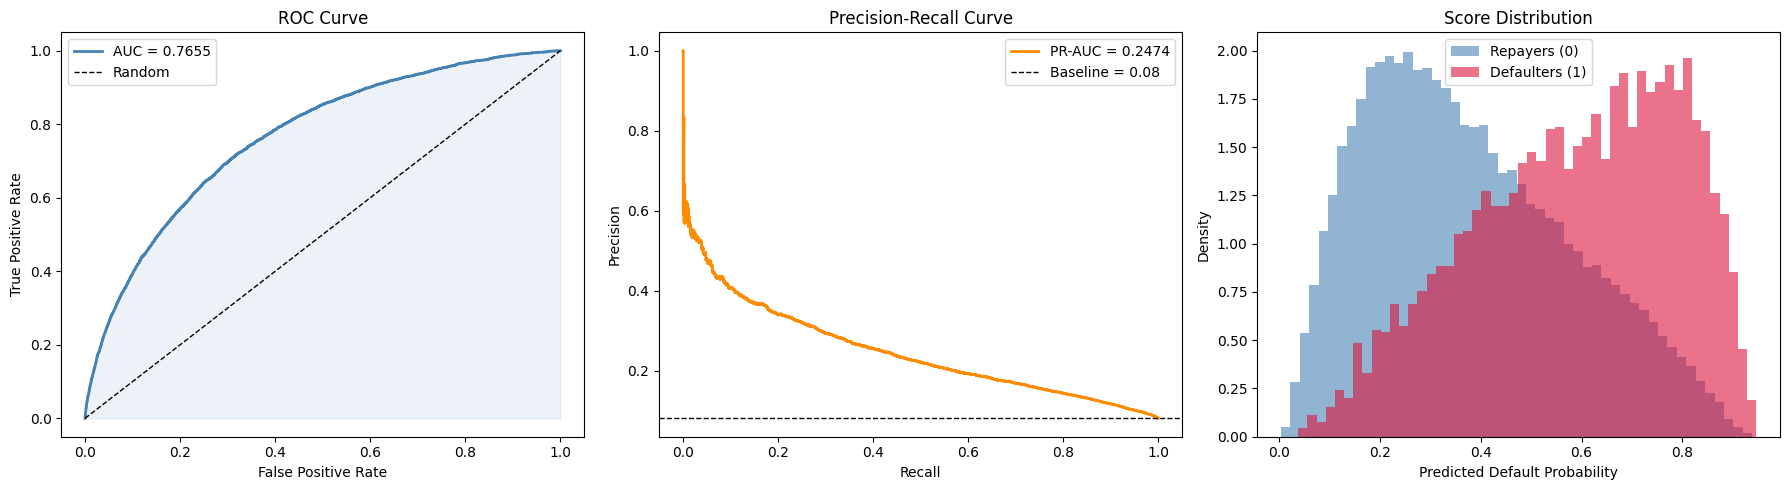

In [7]:
# CELL 5
# Get predictions
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred_class = (y_pred_proba >= 0.5).astype(int)

# Metrics
roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc  = average_precision_score(y_test, y_pred_proba)

# KS Statistic
defaulter_scores = y_pred_proba[y_test == 1]
repayer_scores   = y_pred_proba[y_test == 0]
ks_stat = max(
    abs(
        np.searchsorted(np.sort(defaulter_scores), t) / len(defaulter_scores) -
        np.searchsorted(np.sort(repayer_scores), t)   / len(repayer_scores)
    )
    for t in np.linspace(0, 1, 100)
)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_class)
tn, fp, fn, tp = cm.ravel()

print(f"{'='*45}")
print(f"  TUNED MODEL PERFORMANCE")
print(f"{'='*45}")
print(f"  ROC-AUC  : {roc_auc:.4f}")
print(f"  PR-AUC   : {pr_auc:.4f}")
print(f"  KS Stat  : {ks_stat:.4f}")
print(f"{'='*45}")

print(f"\nConfusion Matrix:")
print(f"  True Negatives  : {tn:,}")
print(f"  False Positives : {fp:,}")
print(f"  False Negatives : {fn:,}")
print(f"  True Positives  : {tp:,}")

print(f"\nOf {y_test.sum():,} actual defaulters:")
print(f"  Caught : {tp:,}  ({tp/y_test.sum():.1%})")
print(f"  Missed : {fn:,}  ({fn/y_test.sum():.1%})")

# Compare before and after tuning
print(f"\nBefore vs After Tuning:")
print(f"{'='*40}")
print(f"  {'Metric':<12} {'Before':>10} {'After':>10}")
print(f"{'='*40}")
print(f"  {'ROC-AUC':<12} {'0.7642':>10} {roc_auc:>10.4f}")
print(f"  {'PR-AUC':<12} {'0.2454':>10} {pr_auc:>10.4f}")
print(f"  {'KS Stat':<12} {'0.3961':>10} {ks_stat:>10.4f}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[0].plot([0,1],[0,1], 'k--', lw=1, label='Random')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
axes[1].plot(recall, precision, color='darkorange', lw=2,
             label=f'PR-AUC = {pr_auc:.4f}')
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--',
                lw=1, label=f'Baseline = {y_test.mean():.2f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

axes[2].hist(repayer_scores,   bins=50, alpha=0.6,
             color='steelblue', label='Repayers (0)', density=True)
axes[2].hist(defaulter_scores, bins=50, alpha=0.6,
             color='crimson',   label='Defaulters (1)', density=True)
axes[2].set_xlabel('Predicted Default Probability')
axes[2].set_ylabel('Density')
axes[2].set_title('Score Distribution')
axes[2].legend()

plt.tight_layout()
plt.savefig('../data/model_evaluation_tuned.png', dpi=150)
plt.show()


In [8]:
import json

# Save feature names in correct order
feature_names = X_train.columns.tolist()

# Save median values for all features
# API will use these to fill columns not provided by user
feature_medians = X_train.median().to_dict()

# Save both to disk
metadata = {
    'feature_names'   : feature_names,
    'feature_medians' : feature_medians
}

with open('../app/feature_metadata.json', 'w') as f:
    json.dump(metadata, f)

print(f"Feature metadata saved ✅")
print(f"  Total features : {len(feature_names)}")
print(f"  Sample features: {feature_names[:5]}")

Feature metadata saved ✅
  Total features : 190
  Sample features: ['NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL']


In [9]:
# CELL 7

import os
os.makedirs('../app/model_artifacts', exist_ok=True)

# Save model directly as XGBoost file
model.save_model('../app/model_artifacts/xgboost_model.json')
print("Model saved ✅")

# Verify file exists
import os
size = os.path.getsize('../app/model_artifacts/xgboost_model.json')
print(f"File size : {size/1024:.1f} KB")

Model saved ✅
File size : 1170.5 KB


In [10]:
# CELL 8